## Data exploration

The data here is the latest 5 years (2019-2024) [Road Safety Data](https://www.gov.uk/government/statistical-data-sets/road-safety-open-data), which was relesased by DfT. 

The data was recorded following the **STATS19 collision** reporting system.

In [8]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
pd.set_option('display.max_columns', None)

In [9]:
# --- STEP 1: GEOSPATIAL FILTERING (London Scope) ---
# Load London LSOA (Lower Layer Super Output Area) boundaries to define the geographic study area
lon_lsoa = gpd.read_file('../Data/statistical-gis-boundaries-london/ESRI/LSOA_2011_London_gen_MHW.shp')

# Load raw collision data (contains coordinates and environmental factors)
collision = pd.read_csv('../Data/dft-road-casualty-statistics-collision-last-5-years.csv')

# Perform an inner merge to keep only accidents that occurred within London LSOA boundaries
lon_collision_5Y = lon_lsoa.merge(collision, left_on='LSOA11CD', right_on='lsoa_of_accident_location', how='inner')

# Data Deduplication: STATS19 records can sometimes overlap or be recorded multiple times
lon_collision_5Y = lon_collision_5Y.drop_duplicates(subset=["collision_ref_no"], keep='first')

# --- STEP 2: PEDESTRIAN CASUALTY PROCESSING ---
# Load casualty data (contains details about people injured)
casualty = pd.read_csv('../Data/dft-road-casualty-statistics-casualty-last-5-years.csv')

# Filter for Pedestrians only (casualty_type == 0 is the code for pedestrians in STATS19)
pedestrain_casualty = casualty[casualty["casualty_type"] == 0]

# One accident can have multiple casualties. We prioritize the most severe injury 
# (Note: In STATS19, 1 = Fatal, 2 = Serious, 3 = Slight, so ascending order captures highest severity)
pedestrain_most_severe = pedestrain_casualty.sort_values(
    by=['collision_index', 'casualty_severity'], 
    ascending=[True, True]
).drop_duplicates(subset=['collision_index'], keep='first')

# --- STEP 3: VEHICLE & MULTI-TABLE INTEGRATION ---
# Load vehicle data (contains details about engine size, vehicle age, etc.)
vehicle = pd.read_csv('../Data/dft-road-casualty-statistics-vehicle-last-5-years.csv')

# Merge filtered London collisions with the most severe pedestrian casualty records
lon_pedestrain_casualty_collision = pd.merge(pedestrain_most_severe, lon_collision_5Y, on='collision_index', how='inner')

# Join with vehicle data to identify the vehicle involved in the pedestrian hit
lon_pedestrain_collision_5y = pd.merge(lon_pedestrain_casualty_collision, vehicle, on='collision_index', how='left')

# In multi-vehicle accidents, filter for the primary vehicle (reference 1) to simplify the analysis
# to the most likely vehicle that struck the pedestrian.
lon_pedestrain_collision_5y = lon_pedestrain_collision_5y[lon_pedestrain_collision_5y["vehicle_reference_y"] == 1]

# --- STEP 4: FEATURE SELECTION & CLEANING ---
# Define a subset of features relevant to safety analysis and network modeling
cols_selected = [
    'collision_index', 'longitude', 'latitude',         # Spatial identifiers for network mapping
    'casualty_severity',                               # Target variable (Response)
    'speed_limit', 'light_conditions',                  # Environmental context
    'weather_conditions', 'road_surface_conditions',
    'road_type', 'junction_detail', 'junction_control',
    'urban_or_rural_area', 'time', 'day_of_week',
    'vehicle_type', 'engine_capacity_cc',               # Vehicle characteristics
    'age_of_vehicle', 'propulsion_code'
]
lon_pedestrain_collision_5y = lon_pedestrain_collision_5y[cols_selected].copy()

# Handle missing values: STATS19 uses '-1' to represent 'Data missing or out of range'
# Converting to NaN allows for proper imputation or exclusion during machine learning
lon_pedestrain_collision_5y.replace(-1, np.nan, inplace=True)

# --- STEP 5: TEMPORAL FEATURE ENGINEERING ---
# Extract 'hour' from the 'time' string to create a cyclical numerical feature for the model
lon_pedestrain_collision_5y['hour'] = pd.to_datetime(
    lon_pedestrain_collision_5y['time'], 
    format='%H:%M', 
    errors='coerce'
).dt.hour

# Remove original 'time' string column to maintain feature matrix integrity
lon_pedestrain_collision_5y.drop(columns=['time'], inplace=True)

# Final Integrity Check: Drop rows missing the Target (severity) or spatial data (for BC mapping)
# Without coordinates, the record cannot be snapped to the road network later.
lon_pedestrain_collision_5y.dropna(subset=['casualty_severity'], inplace=True)
lon_pedestrain_collision_5y.dropna(subset=['longitude', 'latitude'], inplace=True)

C:\Users\17902\AppData\Local\Temp\ipykernel_33740\2460084566.py:30: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  vehicle = pd.read_csv('../Data/dft-road-casualty-statistics-vehicle-last-5-years.csv')


In [10]:
lon_pedestrain_collision_5y.notnull().sum()

collision_index            19963
longitude                  19963
latitude                   19963
casualty_severity          19963
speed_limit                19957
light_conditions           19963
weather_conditions         19963
road_surface_conditions    19963
road_type                  19963
junction_detail            18703
junction_control           14648
urban_or_rural_area        19963
day_of_week                19963
vehicle_type               19656
engine_capacity_cc         12791
age_of_vehicle             13443
propulsion_code            13445
hour                       19963
dtype: int64

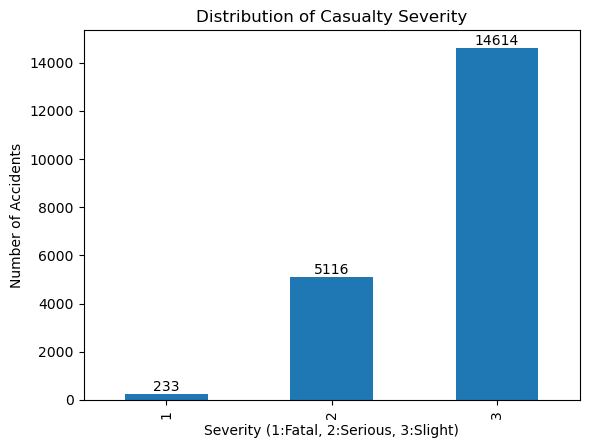

In [11]:
# Plot the bar chart and assign the axis object to 'ax'
ax = lon_pedestrain_collision_5y['casualty_severity'].value_counts().sort_index().plot(
    kind='bar', 
    title='Distribution of Casualty Severity',
    xlabel='Severity (1:Fatal, 2:Serious, 3:Slight)',
    ylabel='Number of Accidents'
)

# Iterate through the list of patches (the bars) to add text labels
for p in ax.patches:
    # Get the height of the bar to use as the label value
    height = p.get_height()
    
    # Place the text at the center of the bar width and slightly above the bar height
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', 
                va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

In [12]:
lon_pedestrain_collision_5y

,collision_index,longitude,latitude,casualty_severity,speed_limit,light_conditions,weather_conditions,road_surface_conditions,road_type,junction_detail,junction_control,urban_or_rural_area,day_of_week,vehicle_type,engine_capacity_cc,age_of_vehicle,propulsion_code,hour
0,2020010219808,-0.254001,51.462262,3,20.0,1,9,9,6,0.0,NaN,1,3,9.0,1968.0,6.0,2.0,9
1,2020010220496,-0.139253,51.470327,3,20.0,1,1,1,6,19.0,2.0,1,2,9.0,1395.0,2.0,1.0,13
2,2020010228005,-0.178719,51.529614,3,30.0,4,1,2,6,13.0,1.0,1,4,9.0,NaN,NaN,NaN,1
3,2020010228006,-0.001683,51.541210,2,30.0,4,1,1,6,0.0,NaN,1,4,8.0,1798.0,8.0,8.0,1
4,2020010228011,-0.137592,51.515704,3,30.0,4,1,1,6,13.0,4.0,1,4,9.0,2993.0,4.0,2.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21387,2024481570119,-0.075750,51.513180,3,20.0,4,2,2,6,13.0,4.0,1,5,9.0,1462.0,1.0,8.0,17
21388,2024481570164,-0.076040,51.514510,3,20.0,1,2,2,6,0.0,NaN,1,6,1.0,NaN,NaN,NaN,8
21389,2024481570190,-0.090100,51.513270,2,20.0,4,2,2,3,0.0,NaN,1,4,1.0,NaN,NaN,NaN,17
21390,2024481570205,-0.078630,51.517700,1,20.0,4,1,1,6,0.0,NaN,1,1,98.0,NaN,NaN,NaN,4


In [13]:
import networkx as nx
import osmnx as ox
# G = ox.graph_from_place('London, UK', network_type='drive')
G = ox.load_graphml('../Data/london_network.graphml')

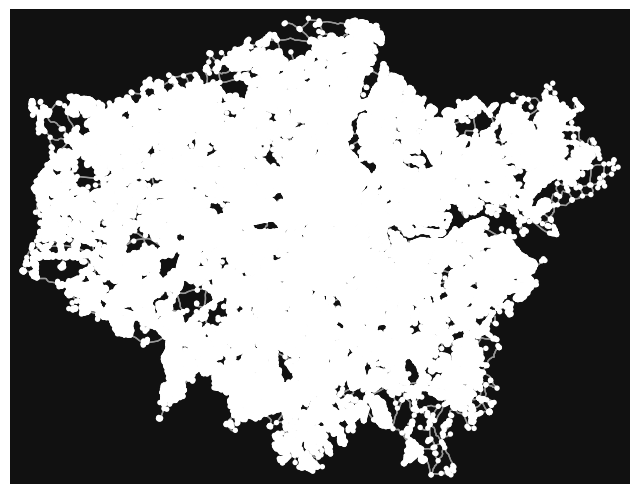

In [14]:
fig, ax = ox.plot_graph(G)

In [15]:
import igraph as ig
import numpy as np
import networkx as nx
import gc
import osmnx as ox

# 1. Clear previous failed variables to free up RAM
if 'edges_list' in locals(): del edges_list
gc.collect()

# Check if simplification is needed
if not G.graph.get("simplified"):
    print("Simplifying graph...")
    G = ox.simplify_graph(G)
else:
    print("Graph is already simplified. Proceeding to ID mapping...")

# 2. Map OSM IDs to small integers
# igraph requires 0-indexed integer IDs. Using long OSM IDs causes MemoryErrors.
nodes = list(G.nodes())
node_map = {node_id: i for i, node_id in enumerate(nodes)}

# 3. Create igraph object with specific vertex count
n_vertices = len(nodes)
g_ig = ig.Graph(n=n_vertices, directed=True)

# 4. Add edges and weights
# We extract data directly to avoid creating large intermediate list objects
print("Adding edges and weights to igraph...")
edges_to_add = []
weights = []

for u, v, d in G.edges(data=True):
    edges_to_add.append((node_map[u], node_map[v]))
    weights.append(d.get('length', 0))

g_ig.add_edges(edges_to_add)
g_ig.es['weight'] = weights

# Explicitly clear temporary lists to save RAM before the heavy calculation
del edges_to_add
gc.collect()

# 5. Calculation with Sampling (k=500)
# Betweenness measures the 'flow' potential of each road segment.
# In pedestrian safety, high betweenness often correlates with high conflict zones.
k = 500 
print(f"Calculating Edge Betweenness (k={k}) using C-based igraph engine...")
sampled_sources = np.random.choice(n_vertices, size=k, replace=False)

# This is the most computationally intensive part
edge_bc_values = g_ig.edge_betweenness(weights='weight', directed=True, sources=sampled_sources)

# 6. Map results back to NetworkX
print("Mapping results back to NetworkX graph...")
edge_bc_dict = {
    (u, v, k_id): edge_bc_values[i] 
    for i, (u, v, k_id) in enumerate(G.edges(keys=True))
}

nx.set_edge_attributes(G, edge_bc_dict, 'edge_bc')

# 7. SAVE IMMEDIATELY
# Saving as GraphML preserves all numerical attributes for your XGBoost model.
output_filename = 'london_road_with_bc.graphml'
ox.save_graphml(G, output_filename)
print(f"Success! Calculation finished and saved to {output_filename}")

Graph is already simplified. Proceeding to ID mapping...
Adding edges and weights to igraph...
Calculating Edge Betweenness (k=500) using C-based igraph engine...
Mapping results back to NetworkX graph...
Success! Calculation finished and saved to london_road_with_bc.graphml


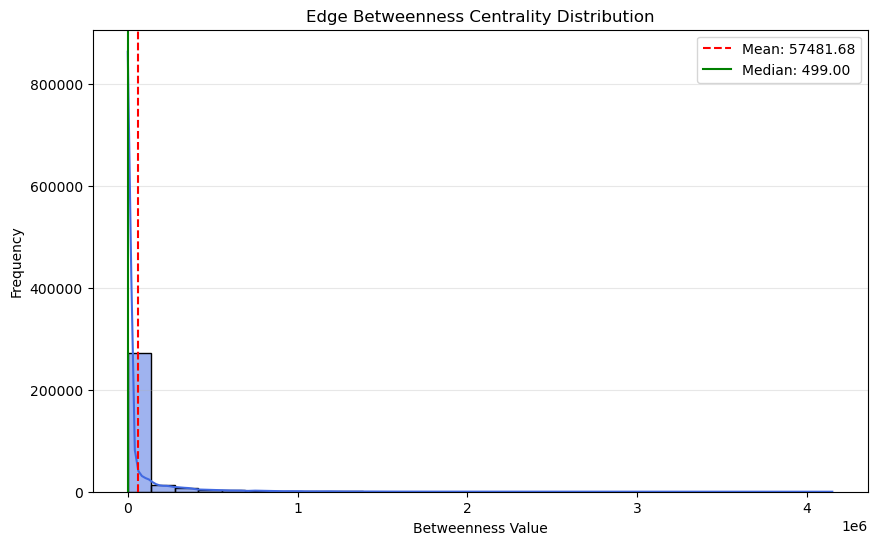

Categorical distribution preview:
category
Low       101307
High      101269
Medium    101229
Name: count, dtype: int64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 提取 dictionary 中的 values
bc_values = list(edge_bc_dict.values())

# 创建 DataFrame 方便操作
df_bc = pd.DataFrame(bc_values, columns=['betweenness'])

# 绘图
plt.figure(figsize=(10, 6))

# 1. 绘制分布直方图 (Histogram) 和 核密度估计 (KDE)
sns.histplot(df_bc['betweenness'], kde=True, color='royalblue', bins=30)

# 添加中位数和均值线以辅助判断如何转换 category
plt.axvline(df_bc['betweenness'].mean(), color='red', linestyle='--', label=f"Mean: {df_bc['betweenness'].mean():.2f}")
plt.axvline(df_bc['betweenness'].median(), color='green', linestyle='-', label=f"Median: {df_bc['betweenness'].median():.2f}")

plt.title('Edge Betweenness Centrality Distribution')
plt.xlabel('Betweenness Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# 2. 转换建议 (如果你想把它转成 category)
# 常见的做法是基于分位数，例如：Low, Medium, High
df_bc['category'] = pd.qcut(df_bc['betweenness'], q=3, labels=['Low', 'Medium', 'High'])

print("Categorical distribution preview:")
print(df_bc['category'].value_counts())

In [17]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# 1. 将 edge_bc_dict 转换为 DataFrame 并与路网 edges 合并
# 假设 G 是你的路网图，edges 是 GeoDataFrame
nodes, edges = ox.graph_to_gdfs(G)

# 将 dictionary 映射到 edges 的索引上
# 注意：edge_bc_dict 的 key 通常是 (u, v, key)
edges['betweenness'] = edges.index.map(edge_bc_dict)

In [18]:
geometry = [Point(xy) for xy in zip(lon_pedestrain_collision_5y['longitude'], lon_pedestrain_collision_5y['latitude'])]
df_gdf = gpd.GeoDataFrame(lon_pedestrain_collision_5y, geometry=geometry, crs="EPSG:4326")

edges = edges.to_crs(epsg=3857)
df_gdf = df_gdf.to_crs(epsg=3857)

In [19]:
# 寻找最近的路段
# distance_col 可以记录事故点偏离路段的具体距离
matched_accidents = gpd.sjoin_nearest(
    df_gdf, 
    edges[['betweenness', 'geometry']], 
    how='left', 
    distance_col="dist_to_road"
)

# 现在 matched_accidents 中已经包含了对应路段的 betweenness 
print(matched_accidents[['geometry', 'betweenness', 'dist_to_road']].head())

# if the distance is larger than 50m, its betweenness will be set as 0
matched_accidents.loc[matched_accidents["dist_to_road"] > 50, "betweenness"] = 0

                         geometry  betweenness  dist_to_road
0   POINT (-28275.262 6703473.48)          0.0      8.951762
0   POINT (-28275.262 6703473.48)        499.0      8.951762
1  POINT (-15501.573 6704914.616)     180030.0      0.883675
2  POINT (-19894.908 6715516.448)      41428.0      0.121910
2  POINT (-19894.908 6715516.448)      55296.0      0.121910


In [20]:
matched_accidents

,collision_index,longitude,latitude,casualty_severity,speed_limit,light_conditions,weather_conditions,road_surface_conditions,road_type,junction_detail,junction_control,urban_or_rural_area,day_of_week,vehicle_type,engine_capacity_cc,age_of_vehicle,propulsion_code,hour,geometry,u,v,key,betweenness,dist_to_road
0,2020010219808,-0.254001,51.462262,3,20.0,1,9,9,6,0.0,NaN,1,3,9.0,1968.0,6.0,2.0,9,POINT (-28275.262 6703473.48),4794294403,4794294404,0,0.0,8.951762
0,2020010219808,-0.254001,51.462262,3,20.0,1,9,9,6,0.0,NaN,1,3,9.0,1968.0,6.0,2.0,9,POINT (-28275.262 6703473.48),4794294404,4794294403,0,499.0,8.951762
1,2020010220496,-0.139253,51.470327,3,20.0,1,1,1,6,19.0,2.0,1,2,9.0,1395.0,2.0,1.0,13,POINT (-15501.573 6704914.616),996609840,110094768,0,180030.0,0.883675
2,2020010228005,-0.178719,51.529614,3,30.0,4,1,2,6,13.0,1.0,1,4,9.0,NaN,NaN,NaN,1,POINT (-19894.908 6715516.448),1664711642,11640595864,0,41428.0,0.121910
2,2020010228005,-0.178719,51.529614,3,30.0,4,1,2,6,13.0,1.0,1,4,9.0,NaN,NaN,NaN,1,POINT (-19894.908 6715516.448),11640595864,1664711642,0,55296.0,0.121910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21389,2024481570190,-0.090100,51.513270,2,20.0,4,2,2,3,0.0,NaN,1,4,1.0,NaN,NaN,NaN,17,POINT (-10029.886 6712592.401),24659947,2387226309,0,0.0,10.074862
21390,2024481570205,-0.078630,51.517700,1,20.0,4,1,1,6,0.0,NaN,1,1,98.0,NaN,NaN,NaN,4,POINT (-8753.052 6713384.853),249560538,302013672,0,0.0,2.050621
21390,2024481570205,-0.078630,51.517700,1,20.0,4,1,1,6,0.0,NaN,1,1,98.0,NaN,NaN,NaN,4,POINT (-8753.052 6713384.853),302013672,249560538,0,499.0,2.050621
21392,2024481570252,-0.106560,51.514220,3,20.0,4,1,1,3,0.0,NaN,1,4,9.0,2996.0,6.0,1.0,0,POINT (-11862.205 6712762.333),1617596711,1617596714,0,19065.0,4.640414


In [21]:
# one collision point may be joined to multi roads
matched_accidents = (
    matched_accidents
    .sort_values('dist_to_road', ascending=True)
    .loc[lambda df: ~df.index.duplicated(keep='first')]
)

In [22]:
matched_accidents

,collision_index,longitude,latitude,casualty_severity,speed_limit,light_conditions,weather_conditions,road_surface_conditions,road_type,junction_detail,junction_control,urban_or_rural_area,day_of_week,vehicle_type,engine_capacity_cc,age_of_vehicle,propulsion_code,hour,geometry,u,v,key,betweenness,dist_to_road
586,2020010235097,-0.117542,51.300717,2,30.0,1,1,1,6,13.0,4.0,1,6,9.0,1999.0,12.0,1.0,11,POINT (-13084.716 6674660.456),102989180,102989181,0,130340.0,0.000698
4273,2021010296098,0.038858,51.540332,3,30.0,1,5,2,3,19.0,4.0,1,4,9.0,1997.0,5.0,8.0,15,POINT (4325.653 6717434.537),9340271599,118241952,0,3741.0,0.000865
18100,2024010501447,-0.482620,51.526270,3,30.0,1,1,1,6,13.0,2.0,1,1,9.0,1349.0,10.0,1.0,11,POINT (-53725.013 6714918.099),26603377,6634718683,0,10779.0,0.001492
4389,2021010298400,-0.073554,51.537907,2,20.0,1,1,1,6,NaN,4.0,1,7,9.0,1397.0,13.0,1.0,17,POINT (-8187.994 6717000.521),3199283543,654181152,0,862.0,0.001800
18720,2024010511959,-0.334550,51.508950,2,20.0,1,1,1,6,13.0,4.0,1,5,9.0,1461.0,8.0,2.0,17,POINT (-37241.936 6711819.7),9451437275,1768503567,0,53790.0,0.001807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5175,2021010312778,-0.230895,51.603576,3,20.0,1,1,1,6,0.0,NaN,1,4,9.0,998.0,12.0,1.0,19,POINT (-25703.114 6728761.869),671131,671132,0,0.0,390.290942
19453,2024010524099,-0.352610,51.623810,3,30.0,4,1,1,6,18.0,4.0,1,1,9.0,NaN,NaN,NaN,1,POINT (-39252.366 6732389.215),490151,60084125,0,0.0,461.386855
19834,2024010530973,0.283340,51.545440,1,70.0,6,2,2,3,0.0,NaN,2,1,8.0,2499.0,9.0,2.0,3,POINT (31541.265 6718348.822),255702890,33323634,0,0.0,469.184193
21105,2024010548852,0.268730,51.596180,1,70.0,1,1,2,3,0.0,NaN,2,5,9.0,2967.0,1.0,2.0,11,POINT (29914.887 6727436.393),30875136,21613915,0,0.0,1500.186617


<Axes: >

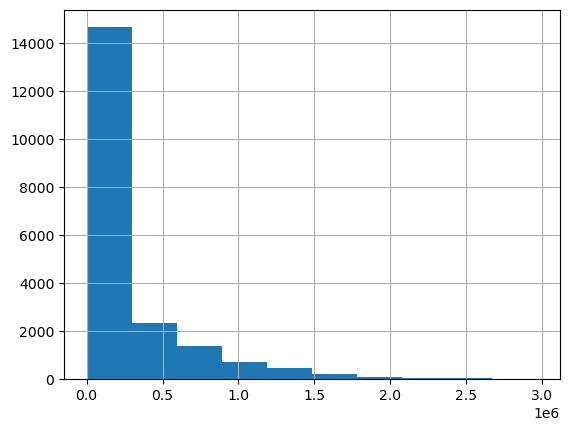

In [23]:
matched_accidents["betweenness"].hist()

In [24]:
len(matched_accidents[matched_accidents["betweenness"] == 0])

2036

In [25]:
len(matched_accidents)

19963

In [26]:
len(matched_accidents[matched_accidents["dist_to_road"]>50])

320

Accident distribution by Road Importance (Betweenness):
bc_level
Zero/Off-road    2036
Low              5976
Medium           5976
High             5975
Name: count, dtype: int64


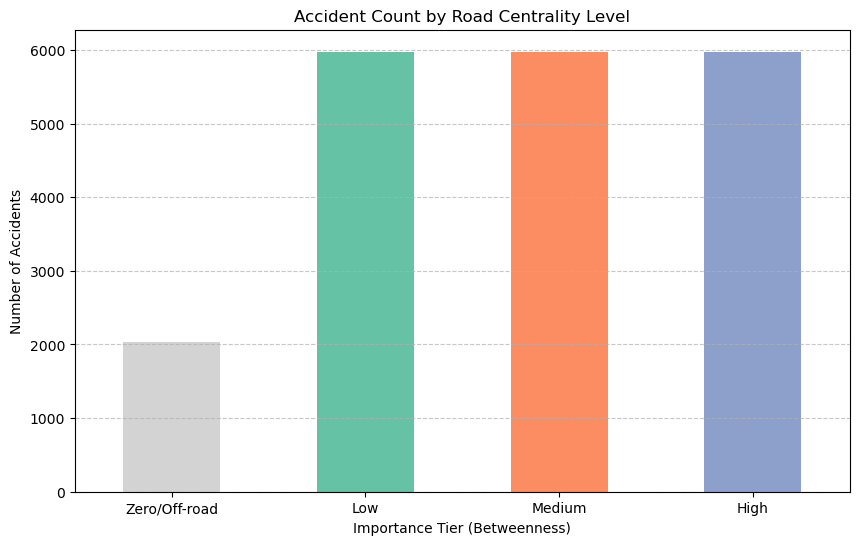

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Separate zero and non-zero values
mask_zero = matched_accidents['betweenness'] == 0
non_zero_data = matched_accidents.loc[~mask_zero, 'betweenness']

# 2. Create categories for non-zero values using quantile cut (3 levels)
# This splits the remaining road segments into 3 equal-sized groups
non_zero_levels = pd.qcut(
    non_zero_data, 
    q=3, 
    labels=['Low', 'Medium', 'High']
)

# 3. Combine them back into the main dataframe
# Initialize with 'Zero/Off-road'
matched_accidents['bc_level'] = 'Zero/Off-road'
# Update the non-zero rows with their respective quantile labels
matched_accidents.loc[~mask_zero, 'bc_level'] = non_zero_levels.astype(str)

# 4. Set order for visualization
category_order = ['Zero/Off-road', 'Low', 'Medium', 'High']
matched_accidents['bc_level'] = pd.Categorical(
    matched_accidents['bc_level'], 
    categories=category_order, 
    ordered=True
)

# 5. Print results
print("Accident distribution by Road Importance (Betweenness):")
print(matched_accidents['bc_level'].value_counts().sort_index())

# 6. Plotting
plt.figure(figsize=(10, 6))
matched_accidents['bc_level'].value_counts().sort_index().plot(
    kind='bar', 
    color=['#d3d3d3', '#66c2a5', '#fc8d62', '#8da0cb']
)
plt.title('Accident Count by Road Centrality Level')
plt.xlabel('Importance Tier (Betweenness)')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [28]:
# 定义映射关系
mapping = {
    'Zero/Off-road': 0,
    'Low': 1,
    'Medium': 2,
    'High': 3
}

# 应用转换
matched_accidents['bc_level_int'] = matched_accidents['bc_level'].map(mapping)

# 检查结果
print(matched_accidents[['bc_level', 'bc_level_int']].head())

      bc_level bc_level_int
586     Medium            2
4273       Low            1
18100      Low            1
4389       Low            1
18720   Medium            2


In [29]:
matched_accidents

,collision_index,longitude,latitude,casualty_severity,speed_limit,light_conditions,weather_conditions,road_surface_conditions,road_type,junction_detail,junction_control,urban_or_rural_area,day_of_week,vehicle_type,engine_capacity_cc,age_of_vehicle,propulsion_code,hour,geometry,u,v,key,betweenness,dist_to_road,bc_level,bc_level_int
586,2020010235097,-0.117542,51.300717,2,30.0,1,1,1,6,13.0,4.0,1,6,9.0,1999.0,12.0,1.0,11,POINT (-13084.716 6674660.456),102989180,102989181,0,130340.0,0.000698,Medium,2
4273,2021010296098,0.038858,51.540332,3,30.0,1,5,2,3,19.0,4.0,1,4,9.0,1997.0,5.0,8.0,15,POINT (4325.653 6717434.537),9340271599,118241952,0,3741.0,0.000865,Low,1
18100,2024010501447,-0.482620,51.526270,3,30.0,1,1,1,6,13.0,2.0,1,1,9.0,1349.0,10.0,1.0,11,POINT (-53725.013 6714918.099),26603377,6634718683,0,10779.0,0.001492,Low,1
4389,2021010298400,-0.073554,51.537907,2,20.0,1,1,1,6,NaN,4.0,1,7,9.0,1397.0,13.0,1.0,17,POINT (-8187.994 6717000.521),3199283543,654181152,0,862.0,0.001800,Low,1
18720,2024010511959,-0.334550,51.508950,2,20.0,1,1,1,6,13.0,4.0,1,5,9.0,1461.0,8.0,2.0,17,POINT (-37241.936 6711819.7),9451437275,1768503567,0,53790.0,0.001807,Medium,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5175,2021010312778,-0.230895,51.603576,3,20.0,1,1,1,6,0.0,NaN,1,4,9.0,998.0,12.0,1.0,19,POINT (-25703.114 6728761.869),671131,671132,0,0.0,390.290942,Zero/Off-road,0
19453,2024010524099,-0.352610,51.623810,3,30.0,4,1,1,6,18.0,4.0,1,1,9.0,NaN,NaN,NaN,1,POINT (-39252.366 6732389.215),490151,60084125,0,0.0,461.386855,Zero/Off-road,0
19834,2024010530973,0.283340,51.545440,1,70.0,6,2,2,3,0.0,NaN,2,1,8.0,2499.0,9.0,2.0,3,POINT (31541.265 6718348.822),255702890,33323634,0,0.0,469.184193,Zero/Off-road,0
21105,2024010548852,0.268730,51.596180,1,70.0,1,1,2,3,0.0,NaN,2,5,9.0,2967.0,1.0,2.0,11,POINT (29914.887 6727436.393),30875136,21613915,0,0.0,1500.186617,Zero/Off-road,0


### try try

In [30]:
import pandas as pd
import numpy as np
import warnings
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# 1. Feature Selection
# Removed 'collision_index' as it is a unique ID and doesn't provide predictive value
feature_cols = [
    'longitude', 'latitude', 'speed_limit', 'light_conditions', 
    'weather_conditions', 'road_surface_conditions', 'road_type', 
    'junction_detail', 'junction_control', 'urban_or_rural_area', 
    'day_of_week', 'vehicle_type', 'engine_capacity_cc', 
    'age_of_vehicle', 'propulsion_code', 'hour', 'bc_level_int']

X = matched_accidents[feature_cols]
y = matched_accidents['casualty_severity']

# 2. Data Cleaning: Handling Missing Values (NaNs)
# Fill numerical missing values with the median to avoid errors in Random Forest
X['engine_capacity_cc'] = X['engine_capacity_cc'].fillna(X['engine_capacity_cc'].median())
X['age_of_vehicle'] = X['age_of_vehicle'].fillna(X['age_of_vehicle'].median())

# 3. Feature Engineering: Cyclic Encoding for 'hour'
# This helps the model understand that hour 23 and hour 0 are close in time
X['hour_sin'] = np.sin(2 * np.pi * X['hour'] / 24)
X['hour_cos'] = np.cos(2 * np.pi * X['hour'] / 24)
# Drop the original 'hour' column as it is now redundant
X = X.drop(columns=['hour'])

# 4. Categorical Encoding: One-Hot Encoding
# Converts text categories into numerical binary columns (0s and 1s)
# drop_first=True prevents multicollinearity by removing one redundant column per category
categorical_cols = [
    'light_conditions', 'weather_conditions', 'road_surface_conditions', 
    'road_type', 'junction_detail', 'junction_control', 
    'urban_or_rural_area', 'day_of_week', 'vehicle_type', 'propulsion_code', 'bc_level_int']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 5. Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=63)

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Use Classifier instead of Regressor
# class_weight='balanced' helps with the imbalance between Fatal/Serious/Slight cases
clf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,       # Limit depth to reduce overfitting
    class_weight='balanced', 
    random_state=42
)

clf.fit(X_train, y_train)

# 2. Evaluate using Classification metrics
y_pred = clf.predict(X_test)

# This will give you much more insight than R-squared
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Check the confusion matrix to see if it's actually identifying serious accidents
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           1       0.11      0.23      0.15        31
           2       0.30      0.35      0.32      1010
           3       0.77      0.72      0.74      2952

    accuracy                           0.62      3993
   macro avg       0.39      0.43      0.40      3993
weighted avg       0.64      0.62      0.63      3993

Confusion Matrix:
[[   7   12   12]
 [  21  352  637]
 [  36  802 2114]]


In [32]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, recall_score
from imblearn.metrics import geometric_mean_score

# ── 1. Data Splitting ────────────────────────────────────────────────────────
# We split into Train (60%), Validation (20%), and Test (20%)
# Validation is essential for manual threshold tuning in multiclass tasks
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=63, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=63, stratify=y_train_full
)

# ── 2. Cross-validation strategy ──────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=63)

# ── 3. Parameter grid ─────────────────────────────────────────────────────────
param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight':      ['balanced', {1: 50, 2: 10, 3: 1}]
}

# ── 4. GridSearch ─────────────────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=63),
    param_grid=param_grid,
    cv=skf,
    scoring='recall_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f"Best Parameters:         {grid_search.best_params_}")
print(f"Best Macro Recall Score: {grid_search.best_score_:.3f}")

# ── 5. Threshold Tuning on Validation Set ────────────────────────────────────
# We use the separate X_val to find thresholds without leaking test info
y_val_proba = best_model.predict_proba(X_val)
thresholds = np.arange(0.05, 0.95, 0.01)

# Tune Fatal threshold (Class 1)
best_t_fatal, best_f1_fatal = 0.5, 0.0
for t in thresholds:
    y_pred_binary = (y_val_proba[:, 0] >= t).astype(int)
    y_true_binary = (y_val == 1).astype(int)
    score = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    if score > best_f1_fatal:
        best_f1_fatal = score
        best_t_fatal  = t

# Tune Serious threshold (Class 2)
best_t_serious, best_f1_serious = 0.5, 0.0
for t in thresholds:
    y_pred_binary = (y_val_proba[:, 1] >= t).astype(int)
    y_true_binary = (y_val == 2).astype(int)
    score = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    if score > best_f1_serious:
        best_f1_serious = score
        best_t_serious  = t

print(f"\n── Optimal Thresholds (from validation set) ──")
print(f"  Fatal:   t = {best_t_fatal:.2f}")
print(f"  Serious: t = {best_t_serious:.2f}")

# ── 6. Prediction Logic with Priority ────────────────────────────────────────
def predict_with_thresholds(proba, t_fatal, t_serious):
    """
    Priority: Fatal (1) > Serious (2) > Slight (3)
    """
    n_samples = proba.shape[0]
    y_pred = np.full(n_samples, 3)          # Default to Slight
    y_pred[proba[:, 1] >= t_serious] = 2    # Assign Serious
    y_pred[proba[:, 0] >= t_fatal]   = 1    # Overwrite with Fatal (Higher Priority)
    return y_pred

# ── 7. Final Evaluation on Test Set ──────────────────────────────────────────
y_test_proba = best_model.predict_proba(X_test)
y_pred_default = best_model.predict(X_test)
y_pred_tuned   = predict_with_thresholds(y_test_proba, best_t_fatal, best_t_serious)

print("\n" + "="*55)
print("RESULTS: Tuned Thresholds vs Default")
print("="*55)
print(classification_report(y_test, y_pred_tuned, target_names=['Fatal', 'Serious', 'Slight']))

# ── 8. Summary Table ──────────────────────────────────────────────────────────
print("\n── Summary Table ──")
print(f"{'Metric':<30} {'Default':>10} {'Tuned':>10}")
print("-" * 52)

metrics = [
    ("Fatal Recall", [1]),
    ("Serious Recall", [2]),
]

for name, label in metrics:
    val_def = recall_score(y_test, y_pred_default, labels=label, average='macro')
    val_tun = recall_score(y_test, y_pred_tuned, labels=label, average='macro')
    print(f"{name:<30} {val_def:>10.3f} {val_tun:>10.3f}")

f1_def = f1_score(y_test, y_pred_default, average='macro')
f1_tun = f1_score(y_test, y_pred_tuned, average='macro')
print(f"{'Macro F1':<30} {f1_def:>10.3f} {f1_tun:>10.3f}")

g_def = geometric_mean_score(y_test, y_pred_default, average='macro')
g_tun = geometric_mean_score(y_test, y_pred_tuned, average='macro')
print(f"{'G-mean':<30} {g_def:>10.3f} {g_tun:>10.3f}")

Best Parameters:         {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best Macro Recall Score: 0.400

── Optimal Thresholds (from validation set) ──
  Fatal:   t = 0.31
  Serious: t = 0.35

RESULTS: Tuned Thresholds vs Default
              precision    recall  f1-score   support

       Fatal       0.17      0.19      0.18        47
     Serious       0.27      0.94      0.42      1023
      Slight       0.86      0.11      0.19      2923

    accuracy                           0.32      3993
   macro avg       0.43      0.41      0.26      3993
weighted avg       0.70      0.32      0.25      3993


── Summary Table ──
Metric                            Default      Tuned
----------------------------------------------------
Fatal Recall                        0.085      0.191
Serious Recall                      0.368      0.936
Macro F1                            0.399      0.264
G-mean                              0.525      0.532


## Baseline model

In [33]:
lon_pedestrain_collision_5y.columns

Index(['collision_index', 'longitude', 'latitude', 'casualty_severity',
       'speed_limit', 'light_conditions', 'weather_conditions',
       'road_surface_conditions', 'road_type', 'junction_detail',
       'junction_control', 'urban_or_rural_area', 'day_of_week',
       'vehicle_type', 'engine_capacity_cc', 'age_of_vehicle',
       'propulsion_code', 'hour'],
      dtype='object')

In [34]:
import pandas as pd
import numpy as np
import warnings
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# 1. Feature Selection
# Removed 'collision_index' as it is a unique ID and doesn't provide predictive value
feature_cols = [
    'longitude', 'latitude', 'speed_limit', 'light_conditions', 
    'weather_conditions', 'road_surface_conditions', 'road_type', 
    'junction_detail', 'junction_control', 'urban_or_rural_area', 
    'day_of_week', 'vehicle_type', 'engine_capacity_cc', 
    'age_of_vehicle', 'propulsion_code', 'hour'
]

X = lon_pedestrain_collision_5y[feature_cols]
y = lon_pedestrain_collision_5y['casualty_severity']

# 2. Data Cleaning: Handling Missing Values (NaNs)
# Fill numerical missing values with the median to avoid errors in Random Forest
X['engine_capacity_cc'] = X['engine_capacity_cc'].fillna(X['engine_capacity_cc'].median())
X['age_of_vehicle'] = X['age_of_vehicle'].fillna(X['age_of_vehicle'].median())

# 3. Feature Engineering: Cyclic Encoding for 'hour'
# This helps the model understand that hour 23 and hour 0 are close in time
X['hour_sin'] = np.sin(2 * np.pi * X['hour'] / 24)
X['hour_cos'] = np.cos(2 * np.pi * X['hour'] / 24)
# Drop the original 'hour' column as it is now redundant
X = X.drop(columns=['hour'])

# 4. Categorical Encoding: One-Hot Encoding
# Converts text categories into numerical binary columns (0s and 1s)
# drop_first=True prevents multicollinearity by removing one redundant column per category
categorical_cols = [
    'light_conditions', 'weather_conditions', 'road_surface_conditions', 
    'road_type', 'junction_detail', 'junction_control', 
    'urban_or_rural_area', 'day_of_week', 'vehicle_type', 'propulsion_code'
]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 5. Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

With RandomForestRegressor (baseline)

In [35]:
# 6. Model Training
# Initializing Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 7. Model Evaluation
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculate R-squared scores
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f'Train R-squared: {r2_train:.3f}')
print(f'Test R-squared: {r2_test:.3f}')

# Optional: Calculate Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f'Test RMSE: {rmse:.3f}')

Train R-squared: 0.860
Test R-squared: -0.010
Test RMSE: 0.474


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Use Classifier instead of Regressor
# class_weight='balanced' helps with the imbalance between Fatal/Serious/Slight cases
clf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,       # Limit depth to reduce overfitting
    class_weight='balanced', 
    random_state=42
)

clf.fit(X_train, y_train)

# 2. Evaluate using Classification metrics
y_pred = clf.predict(X_test)

# This will give you much more insight than R-squared
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Check the confusion matrix to see if it's actually identifying serious accidents
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           1       0.15      0.27      0.19        44
           2       0.29      0.36      0.32      1020
           3       0.76      0.69      0.73      2929

    accuracy                           0.60      3993
   macro avg       0.40      0.44      0.41      3993
weighted avg       0.64      0.60      0.62      3993

Confusion Matrix:
[[  12   23    9]
 [  27  365  628]
 [  43  852 2034]]


RandomForestRegressor with Cross Validation

In [10]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1. Define the cross-validation strategy
# 5 folds is standard; shuffle=True is good practice
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Set up the parameter grid
# Don't make it too large or it will take forever to run
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', {1: 500, 2: 10, 3: 1}] # Testing different weight strategies
}

# 3. Initialize GridSearch with Stratified CV and a better scoring metric
# Using 'f1_macro' ensures the model cares about the Fatal/Serious classes
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=63),
    param_grid=param_grid,
    cv=skf,
    scoring='recall_macro', 
    n_jobs=-1 # Use all CPU cores to speed it up
)

# 4. Fit the model
grid_search.fit(X_train, y_train)

# 5. Check results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Macro Recall Score: {grid_search.best_score_:.3f}")

Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Best Macro Recall Score: 0.416


adding threshold tuning

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, recall_score
from imblearn.metrics import geometric_mean_score

# ── 1. Data Splitting ────────────────────────────────────────────────────────
# We split into Train (60%), Validation (20%), and Test (20%)
# Validation is essential for manual threshold tuning in multiclass tasks
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=63, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=63, stratify=y_train_full
)

# ── 2. Cross-validation strategy ──────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=63)

# ── 3. Parameter grid ─────────────────────────────────────────────────────────
param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight':      ['balanced', {1: 50, 2: 10, 3: 1}]
}

# ── 4. GridSearch ─────────────────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=63),
    param_grid=param_grid,
    cv=skf,
    scoring='recall_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f"Best Parameters:         {grid_search.best_params_}")
print(f"Best Macro Recall Score: {grid_search.best_score_:.3f}")

# ── 5. Threshold Tuning on Validation Set ────────────────────────────────────
# We use the separate X_val to find thresholds without leaking test info
y_val_proba = best_model.predict_proba(X_val)
thresholds = np.arange(0.05, 0.95, 0.01)

# Tune Fatal threshold (Class 1)
best_t_fatal, best_f1_fatal = 0.5, 0.0
for t in thresholds:
    y_pred_binary = (y_val_proba[:, 0] >= t).astype(int)
    y_true_binary = (y_val == 1).astype(int)
    score = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    if score > best_f1_fatal:
        best_f1_fatal = score
        best_t_fatal  = t

# Tune Serious threshold (Class 2)
best_t_serious, best_f1_serious = 0.5, 0.0
for t in thresholds:
    y_pred_binary = (y_val_proba[:, 1] >= t).astype(int)
    y_true_binary = (y_val == 2).astype(int)
    score = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    if score > best_f1_serious:
        best_f1_serious = score
        best_t_serious  = t

print(f"\n── Optimal Thresholds (from validation set) ──")
print(f"  Fatal:   t = {best_t_fatal:.2f}")
print(f"  Serious: t = {best_t_serious:.2f}")

# ── 6. Prediction Logic with Priority ────────────────────────────────────────
def predict_with_thresholds(proba, t_fatal, t_serious):
    """
    Priority: Fatal (1) > Serious (2) > Slight (3)
    """
    n_samples = proba.shape[0]
    y_pred = np.full(n_samples, 3)          # Default to Slight
    y_pred[proba[:, 1] >= t_serious] = 2    # Assign Serious
    y_pred[proba[:, 0] >= t_fatal]   = 1    # Overwrite with Fatal (Higher Priority)
    return y_pred

# ── 7. Final Evaluation on Test Set ──────────────────────────────────────────
y_test_proba = best_model.predict_proba(X_test)
y_pred_default = best_model.predict(X_test)
y_pred_tuned   = predict_with_thresholds(y_test_proba, best_t_fatal, best_t_serious)

print("\n" + "="*55)
print("RESULTS: Tuned Thresholds vs Default")
print("="*55)
print(classification_report(y_test, y_pred_tuned, target_names=['Fatal', 'Serious', 'Slight']))

# ── 8. Summary Table ──────────────────────────────────────────────────────────
print("\n── Summary Table ──")
print(f"{'Metric':<30} {'Default':>10} {'Tuned':>10}")
print("-" * 52)

metrics = [
    ("Fatal Recall", [1]),
    ("Serious Recall", [2]),
]

for name, label in metrics:
    val_def = recall_score(y_test, y_pred_default, labels=label, average='macro')
    val_tun = recall_score(y_test, y_pred_tuned, labels=label, average='macro')
    print(f"{name:<30} {val_def:>10.3f} {val_tun:>10.3f}")

f1_def = f1_score(y_test, y_pred_default, average='macro')
f1_tun = f1_score(y_test, y_pred_tuned, average='macro')
print(f"{'Macro F1':<30} {f1_def:>10.3f} {f1_tun:>10.3f}")

g_def = geometric_mean_score(y_test, y_pred_default, average='macro')
g_tun = geometric_mean_score(y_test, y_pred_tuned, average='macro')
print(f"{'G-mean':<30} {g_def:>10.3f} {g_tun:>10.3f}")

Best Parameters:         {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Best Macro Recall Score: 0.401

── Optimal Thresholds (from validation set) ──
  Fatal:   t = 0.35
  Serious: t = 0.36

RESULTS: Tuned Thresholds vs Default
              precision    recall  f1-score   support

       Fatal       0.17      0.19      0.18        47
     Serious       0.27      0.92      0.42      1023
      Slight       0.85      0.13      0.22      2923

    accuracy                           0.33      3993
   macro avg       0.43      0.41      0.27      3993
weighted avg       0.69      0.33      0.27      3993


── Summary Table ──
Metric                            Default      Tuned
----------------------------------------------------
Fatal Recall                        0.191      0.191
Serious Recall                      0.371      0.919
Macro F1                            0.420      0.273
G-mean                              0.547      0.533


when model is unsure, it simply gives prediction of "Serious"...

In [14]:
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, recall_score
from imblearn.metrics import geometric_mean_score

# ── 1. Data Splitting ────────────────────────────────────────────────────────
# Split into Train (60%), Validation (20%), and Test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=63, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=63, stratify=y_train_full
)

# ── 2. Model Training with GridSearch ────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=63)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', {1: 50, 2: 10, 3: 1}]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=63),
    param_grid=param_grid,
    cv=skf,
    scoring='recall_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# ── 3. Prediction Logic with Priority ────────────────────────────────────────
def predict_with_thresholds(proba, t_fatal, t_serious):
    """
    Priority-based prediction: Fatal (1) > Serious (2) > Slight (3)
    """
    n_samples = proba.shape[0]
    y_pred = np.full(n_samples, 3)          # Default category: Slight
    y_pred[proba[:, 1] >= t_serious] = 2    # Assign Serious
    y_pred[proba[:, 0] >= t_fatal]   = 1    # Overwrite with Fatal (Higher Priority)
    return y_pred

# ── 4. Joint Threshold Optimization (Grid Search for G-mean) ────────────────
y_val_proba = best_model.predict_proba(X_val)

best_t_fatal   = 0.5
best_t_serious = 0.5
best_gmean     = 0.0

# Define search ranges for thresholds
# Lowering Fatal threshold to catch more rare cases
# Serious threshold range prevents it from overwhelming Slight
fatal_range   = np.arange(0.05, 0.50, 0.05)
serious_range = np.arange(0.20, 0.60, 0.05)

for t_f in fatal_range:
    for t_s in serious_range:
        y_pred_temp = predict_with_thresholds(y_val_proba, t_f, t_s)
        
        # Calculate Macro G-mean to balance sensitivity across all classes
        current_gmean = geometric_mean_score(y_val, y_pred_temp, average='macro')
        
        if current_gmean > best_gmean:
            best_gmean     = current_gmean
            best_t_fatal   = t_f
            best_t_serious = t_s

print(f"\n── Optimal Thresholds Found ──")
print(f"Best Fatal Threshold:   {best_t_fatal:.2f}")
print(f"Best Serious Threshold: {best_t_serious:.2f}")
print(f"Best G-mean on Val:     {best_gmean:.3f}")

# ── 5. Final Evaluation on Test Set ──────────────────────────────────────────
y_test_proba = best_model.predict_proba(X_test)
y_pred_default = best_model.predict(X_test)
y_pred_tuned   = predict_with_thresholds(y_test_proba, best_t_fatal, best_t_serious)

print("\n" + "="*55)
print("FINAL TEST RESULTS (Optimized for G-mean)")
print("="*55)
print(classification_report(y_test, y_pred_tuned, target_names=['Fatal', 'Serious', 'Slight']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

# ── 6. Summary Comparison ────────────────────────────────────────────────────
print("\n── Performance Comparison ──")
print(f"{'Metric':<30} {'Default':>10} {'Tuned':>10}")
print("-" * 52)

# Metrics calculation
metrics_to_show = [
    ("Fatal Recall", [1]),
    ("Serious Recall", [2]),
    ("Slight Recall", [3])
]

for name, label in metrics_to_show:
    rec_def = recall_score(y_test, y_pred_default, labels=label, average='macro')
    rec_tun = recall_score(y_test, y_pred_tuned, labels=label, average='macro')
    print(f"{name:<30} {rec_def:>10.3f} {rec_tun:>10.3f}")

f1_def = f1_score(y_test, y_pred_default, average='macro')
f1_tun = f1_score(y_test, y_pred_tuned, average='macro')
g_def  = geometric_mean_score(y_test, y_pred_default, average='macro')
g_tun  = geometric_mean_score(y_test, y_pred_tuned, average='macro')

print(f"{'Macro F1':<30} {f1_def:>10.3f} {f1_tun:>10.3f}")
print(f"{'G-mean (Target)':<30} {g_def:>10.3f} {g_tun:>10.3f}")


── Optimal Thresholds Found ──
Best Fatal Threshold:   0.25
Best Serious Threshold: 0.40
Best G-mean on Val:     0.565

FINAL TEST RESULTS (Optimized for G-mean)
              precision    recall  f1-score   support

       Fatal       0.05      0.38      0.10        47
     Serious       0.28      0.68      0.40      1023
      Slight       0.80      0.34      0.48      2923

    accuracy                           0.43      3993
   macro avg       0.38      0.47      0.33      3993
weighted avg       0.66      0.43      0.45      3993

Confusion Matrix:
[[  18   21    8]
 [  98  691  234]
 [ 213 1713  997]]

── Performance Comparison ──
Metric                            Default      Tuned
----------------------------------------------------
Fatal Recall                        0.191      0.383
Serious Recall                      0.371      0.675
Slight Recall                       0.715      0.341
Macro F1                            0.420      0.325
G-mean (Target)                    

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Use the best model found by GridSearchCV to make predictions
# Replace 'grid_search' with the variable name of your GridSearchCV object
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# 2. Generate the Classification Report
# This provides Precision, Recall, and F1-score for every class
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 3. Optional: Generate a Confusion Matrix to see exactly where errors happen
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           1       0.14      0.27      0.18        44
           2       0.31      0.42      0.35      1020
           3       0.77      0.66      0.71      2929

    accuracy                           0.60      3993
   macro avg       0.41      0.45      0.42      3993
weighted avg       0.65      0.60      0.62      3993

Confusion Matrix:
[[  12   23    9]
 [  34  429  557]
 [  40  953 1936]]


#### G-mean

In [26]:
from sklearn.metrics import make_scorer
from imblearn.metrics import geometric_mean_score

# 1. Create a custom scorer for G-Mean
# This allows GridSearchCV to "understand" G-Mean
gmean_scorer = make_scorer(geometric_mean_score)

# 2. Update your GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=63),
    param_grid=param_grid,
    cv=skf,
    scoring=gmean_scorer, # Use the custom G-Mean scorer here
    n_jobs=-1 
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best G-Mean Score: {grid_search.best_score_:.3f}")

Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Best G-Mean Score: 0.346


--- MODEL PERFORMANCE SUMMARY ---
Overall Accuracy: 0.588
Geometric Mean Score: 0.379

Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.10      0.20      0.13        44
           2       0.30      0.41      0.34      1020
           3       0.77      0.66      0.71      2929

    accuracy                           0.59      3993
   macro avg       0.39      0.42      0.39      3993
weighted avg       0.64      0.59      0.61      3993



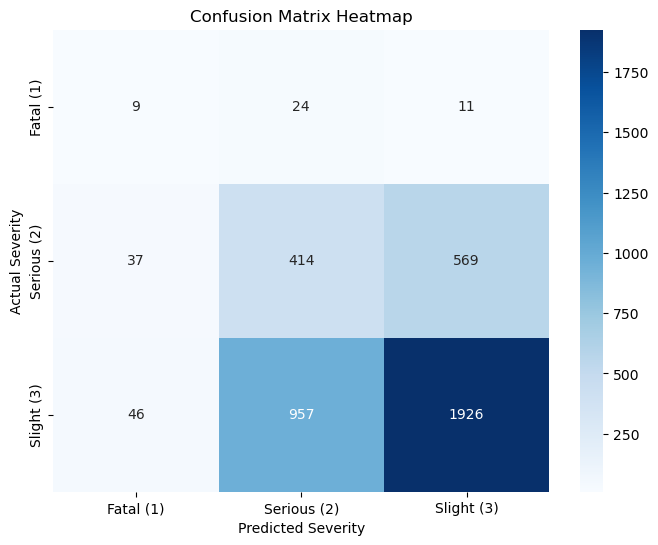

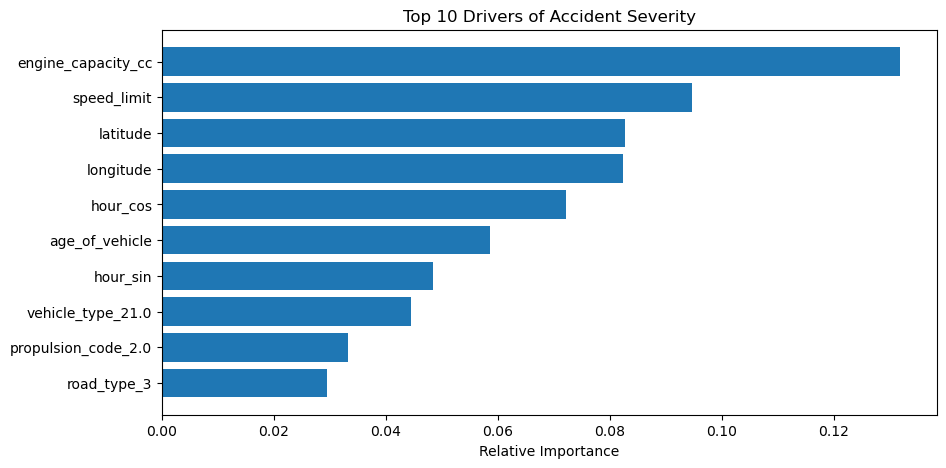

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.metrics import geometric_mean_score

# 1. Get predictions from your best model
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# 2. Print Summary Metrics
print("--- MODEL PERFORMANCE SUMMARY ---")
# G-Mean is crucial for imbalanced data like yours
g_mean = geometric_mean_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"Overall Accuracy: {accuracy:.3f}")
print(f"Geometric Mean Score: {g_mean:.3f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 3. Visual Confusion Matrix (Heatmap)
# This makes it easier to see if Fatal is being confused with Serious or Slight
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fatal (1)', 'Serious (2)', 'Slight (3)'],
            yticklabels=['Fatal (1)', 'Serious (2)', 'Slight (3)'])
plt.xlabel('Predicted Severity')
plt.ylabel('Actual Severity')
plt.title('Confusion Matrix Heatmap')
plt.show()

# 4. Feature Importance (Why is the model making these choices?)
# This helps explain the "outcomes" by showing which factors caused the prediction
importances = best_rf.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10 features

plt.figure(figsize=(10, 5))
plt.title("Top 10 Drivers of Accident Severity")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### XGBOOST

In [16]:
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, recall_score
from imblearn.metrics import geometric_mean_score
from xgboost import XGBClassifier

# ── 1. Data Splitting ────────────────────────────────────────────────────────
# Split into Train (60%), Validation (20%), and Test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=63, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=63, stratify=y_train_full
)

# XGBoost expects labels starting from 0. 
# If your classes are [1, 2, 3], we map them to [0, 1, 2]
y_train_xgb = y_train - 1
y_val_xgb   = y_val - 1
y_test_xgb  = y_test - 1

# ── 2. XGBoost Training with GridSearch ──────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=63)

# Parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10],
    'learning_rate': [0.05, 0.1],
    'tree_method': ['hist'],
    'device': ['cuda'] # Utilizing your RTX 3070
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=63),
    param_grid=param_grid,
    cv=skf,
    scoring='recall_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train_xgb)
best_xgb = grid_search.best_estimator_

print(f"Best XGB Parameters: {grid_search.best_params_}")

# ── 3. Prediction Logic with Priority ────────────────────────────────────────
def predict_with_thresholds(proba, t_fatal, t_serious):
    """
    Priority-based prediction: Fatal (Class 0) > Serious (Class 1) > Slight (Class 2)
    Input proba indices: 0: Fatal, 1: Serious, 2: Slight
    """
    n_samples = proba.shape[0]
    y_pred = np.full(n_samples, 2)          # Default category: Slight (mapped as 2)
    y_pred[proba[:, 1] >= t_serious] = 1    # Assign Serious
    y_pred[proba[:, 0] >= t_fatal]   = 0    # Overwrite with Fatal (Highest Priority)
    return y_pred

# ── 4. Joint Threshold Optimization for G-mean ─────────────────────────────
y_val_proba = best_xgb.predict_proba(X_val)

best_t_fatal   = 0.5
best_t_serious = 0.5
best_gmean     = 0.0

# Define search ranges
fatal_range   = np.arange(0.05, 0.50, 0.05)
serious_range = np.arange(0.15, 0.60, 0.05)

for t_f in fatal_range:
    for t_s in serious_range:
        y_pred_temp = predict_with_thresholds(y_val_proba, t_f, t_s)
        
        # Calculate Macro G-mean on validation set
        current_gmean = geometric_mean_score(y_val_xgb, y_pred_temp, average='macro')
        
        if current_gmean > best_gmean:
            best_gmean     = current_gmean
            best_t_fatal   = t_f
            best_t_serious = t_s

print(f"\n── Optimal Thresholds Found (XGBoost) ──")
print(f"Best Fatal Threshold:   {best_t_fatal:.2f}")
print(f"Best Serious Threshold: {best_t_serious:.2f}")
print(f"Best G-mean on Val:     {best_gmean:.3f}")

# ── 5. Final Evaluation on Test Set ──────────────────────────────────────────
y_test_proba = best_xgb.predict_proba(X_test)
y_pred_default = best_xgb.predict(X_test)
y_pred_tuned   = predict_with_thresholds(y_test_proba, best_t_fatal, best_t_serious)

print("\n" + "="*55)
print("FINAL XGBOOST TEST RESULTS")
print("="*55)
# Mapping back to original classes [1, 2, 3] for the report
print(classification_report(y_test_xgb, y_pred_tuned, target_names=['Fatal', 'Serious', 'Slight']))

# ── 6. Summary Comparison ────────────────────────────────────────────────────
print("\n── Performance Comparison ──")
print(f"{'Metric':<30} {'Default':>10} {'Tuned':>10}")
print("-" * 52)

metrics_to_show = [
    ("Fatal Recall", [0]),
    ("Serious Recall", [1]),
    ("Slight Recall", [2])
]

for name, label in metrics_to_show:
    rec_def = recall_score(y_test_xgb, y_pred_default, labels=label, average='macro')
    rec_tun = recall_score(y_test_xgb, y_pred_tuned, labels=label, average='macro')
    print(f"{name:<30} {rec_def:>10.3f} {rec_tun:>10.3f}")

g_def = geometric_mean_score(y_test_xgb, y_pred_default, average='macro')
g_tun = geometric_mean_score(y_test_xgb, y_pred_tuned, average='macro')

print(f"{'G-mean (Target)':<30} {g_def:>10.3f} {g_tun:>10.3f}")

Best XGB Parameters: {'device': 'cuda', 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'tree_method': 'hist'}

── Optimal Thresholds Found (XGBoost) ──
Best Fatal Threshold:   0.05
Best Serious Threshold: 0.25
Best G-mean on Val:     0.542

FINAL XGBOOST TEST RESULTS
              precision    recall  f1-score   support

       Fatal       0.08      0.21      0.12        47
     Serious       0.29      0.51      0.37      1023
      Slight       0.77      0.56      0.65      2923

    accuracy                           0.54      3993
   macro avg       0.38      0.43      0.38      3993
weighted avg       0.64      0.54      0.57      3993


── Performance Comparison ──
Metric                            Default      Tuned
----------------------------------------------------
Fatal Recall                        0.043      0.213
Serious Recall                      0.053      0.509
Slight Recall                       0.967      0.556
G-mean (Target)                     0.489   

### Tree based methods